<a href="https://colab.research.google.com/github/Rakshanadevi-S/codelab/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 170M/170M [00:03<00:00, 54.6MB/s]



Training with lambda = 0.001
Lambda: 0.001, Epoch 1, Loss: 40512.0984
Lambda: 0.001, Epoch 2, Loss: 37978.3759
Lambda: 0.001, Epoch 3, Loss: 35310.9510
Lambda: 0.001, Epoch 4, Loss: 32379.6794
Lambda: 0.001, Epoch 5, Loss: 29076.8906

Training with lambda = 0.01
Lambda: 0.01, Epoch 1, Loss: 402748.2490
Lambda: 0.01, Epoch 2, Loss: 377604.5269
Lambda: 0.01, Epoch 3, Loss: 351029.1953
Lambda: 0.01, Epoch 4, Loss: 321812.4644
Lambda: 0.01, Epoch 5, Loss: 288880.3926

Training with lambda = 0.1
Lambda: 0.1, Epoch 1, Loss: 4026809.2109
Lambda: 0.1, Epoch 2, Loss: 3775896.6953
Lambda: 0.1, Epoch 3, Loss: 3510460.3984
Lambda: 0.1, Epoch 4, Loss: 3218574.4922
Lambda: 0.1, Epoch 5, Loss: 2889587.0312

Final Results:
Lambda: 0.001, Accuracy: 50.05%, Sparsity: 38.43%
Lambda: 0.01, Accuracy: 52.69%, Sparsity: 38.52%
Lambda: 0.1, Accuracy: 52.95%, Sparsity: 38.56%


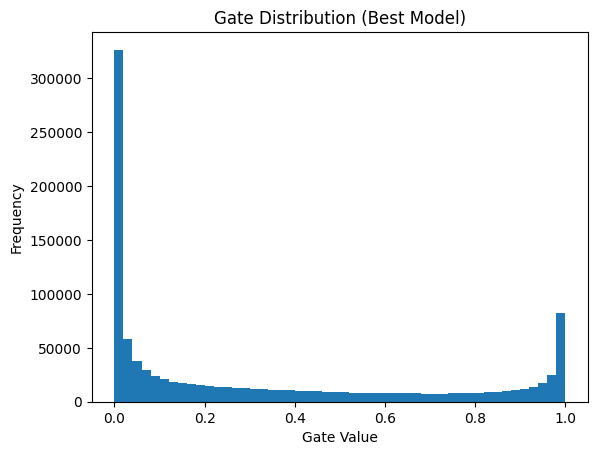

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prunable Linear Layer

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):

        gates = torch.sigmoid(5 * self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.nn.functional.linear(x, pruned_weights, self.bias)

# CNN Model

class PrunableCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.dropout = nn.Dropout(0.5)

        self.fc1 = PrunableLinear(64 * 8 * 8, 256)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def get_sparsity_loss(self):
        loss = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(5 * module.gate_scores)
                loss += torch.sum(torch.abs(gates))
        return loss

    def get_all_gates(self):
        gates_list = []
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(5 * module.gate_scores).detach().cpu().numpy().flatten()
                gates_list.extend(gates)
        return np.array(gates_list)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainset = torch.utils.data.Subset(trainset, range(10000))

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# Training

def train_model(lambda_val, epochs=5):
    model = PrunableCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            cls_loss = criterion(outputs, labels)
            sparsity_loss = model.get_sparsity_loss()

            loss = cls_loss + lambda_val * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda: {lambda_val}, Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

# Evaluation

def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Sparsity

def calculate_sparsity(model, threshold=0.05):
    gates = model.get_all_gates()
    pruned = np.sum(gates < threshold)
    return (pruned / len(gates)) * 100

lambdas = [1e-3, 1e-2, 1e-1]
results = []

best_model = None
best_acc = 0

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    model = train_model(lam)

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model

# Results

print("\nFinal Results:")
for lam, acc, sp in results:
    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sp:.2f}%")

# Plot

gates = best_model.get_all_gates()

plt.hist(gates, bins=50)
plt.title("Gate Distribution (Best Model)")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()